# Modelling For UsedAgain Prediction

In [19]:
import pandas as pd

df = pd.read_csv('../data/processed.csv')
print('Shape:', df.shape)

print('\nUsedAgain dtype / unique values:')
print(df['UsedAgain'].dtype, df['UsedAgain'].value_counts(dropna=False))

print('\nColumns available (sample):')
print(df.columns.tolist())
df.sample(5)

Shape: (10000, 17)

UsedAgain dtype / unique values:
bool UsedAgain
True     7064
False    2936
Name: count, dtype: int64

Columns available (sample):
['SessionID', 'StudentLevel', 'Discipline', 'SessionDate', 'SessionLengthMin', 'TotalPrompts', 'TaskType', 'AI_AssistanceLevel', 'FinalOutcome', 'UsedAgain', 'SatisfactionRating', 'SessionMonth', 'SessionDay', 'Promts_Per_Min', 'duration_bin', 'Discipline_mod', 'StudentLevel_ord']


,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating,SessionMonth,SessionDay,Promts_Per_Min,duration_bin,Discipline_mod,StudentLevel_ord
6587,SESSION06588,High School,Psychology,2024-12-12,11.55,2,Studying,3,Idea Drafted,False,2.5,12,Thursday,0.173160,6-15,Psychology,0
9893,SESSION09894,Graduate,History,2025-02-04,16.45,6,Homework Help,5,Confused,True,5.0,2,Tuesday,0.364742,16-30,History,2
5002,SESSION05003,High School,Business,2024-10-08,23.38,5,Homework Help,3,Assignment Completed,True,3.1,10,Tuesday,0.213858,16-30,Business,0
7598,SESSION07599,Graduate,Psychology,2024-11-11,13.21,4,Brainstorming,3,Gave Up,True,3.6,11,Monday,0.302801,6-15,Psychology,2
4779,SESSION04780,Undergraduate,Psychology,2024-06-24,12.71,4,Homework Help,3,Assignment Completed,True,2.9,6,Monday,0.314713,6-15,Psychology,1


In [20]:
# Simple training example for UsedAgain (readable, step-by-step)
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import joblib
from pathlib import Path


In [21]:

# 1) Choose the features we created in preprocessing
features = [
    'SessionLengthMin','TotalPrompts','AI_AssistanceLevel','SatisfactionRating',
    'SessionMonth','Promts_Per_Min','StudentLevel_ord',
    'Discipline_mod','TaskType','SessionDay','duration_bin'
]
X = df[features].copy()

numeric = ['SessionLengthMin','TotalPrompts','AI_AssistanceLevel','SatisfactionRating','SessionMonth','Promts_Per_Min','StudentLevel_ord']
X[numeric] = X[numeric].fillna(X[numeric].median())
scaler = StandardScaler()
X[numeric] = scaler.fit_transform(X[numeric])

categorical = ['Discipline_mod','TaskType','SessionDay','duration_bin']
X = pd.get_dummies(X, columns=categorical, drop_first=True)


In [22]:

y = df['UsedAgain'].astype(int)


In [23]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:

models = {
    'LogisticRegression': LogisticRegression(max_iter=200, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, class_weight='balanced', random_state=42),
    'NaiveBayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

models_dir = Path('../models/usedAgain')
models_dir.mkdir(parents=True, exist_ok=True)


------------------------------------------------------------
LogisticRegression
Accuracy: 0.517
              precision    recall  f1-score   support

           0       0.30      0.50      0.38       587
           1       0.72      0.52      0.61      1413

    accuracy                           0.52      2000
   macro avg       0.51      0.51      0.49      2000
weighted avg       0.59      0.52      0.54      2000



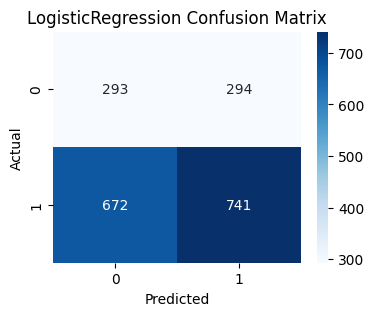

------------------------------------------------------------
RandomForest
Accuracy: 0.699
              precision    recall  f1-score   support

           0       0.37      0.04      0.07       587
           1       0.71      0.97      0.82      1413

    accuracy                           0.70      2000
   macro avg       0.54      0.51      0.44      2000
weighted avg       0.61      0.70      0.60      2000



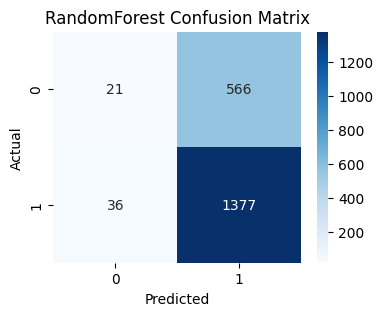

------------------------------------------------------------
KNN
Accuracy: 0.657
              precision    recall  f1-score   support

           0       0.34      0.17      0.23       587
           1       0.71      0.86      0.78      1413

    accuracy                           0.66      2000
   macro avg       0.52      0.52      0.50      2000
weighted avg       0.60      0.66      0.62      2000



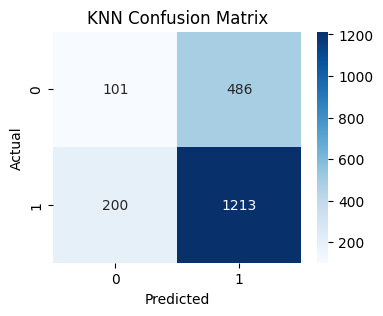

------------------------------------------------------------
SVM
Accuracy: 0.5335
              precision    recall  f1-score   support

           0       0.31      0.47      0.37       587
           1       0.72      0.56      0.63      1413

    accuracy                           0.53      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.60      0.53      0.55      2000



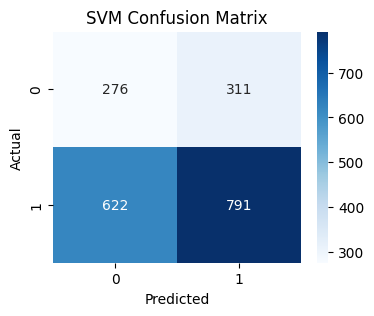

------------------------------------------------------------
NaiveBayes
Accuracy: 0.5365
              precision    recall  f1-score   support

           0       0.31      0.48      0.38       587
           1       0.72      0.56      0.63      1413

    accuracy                           0.54      2000
   macro avg       0.52      0.52      0.50      2000
weighted avg       0.60      0.54      0.56      2000



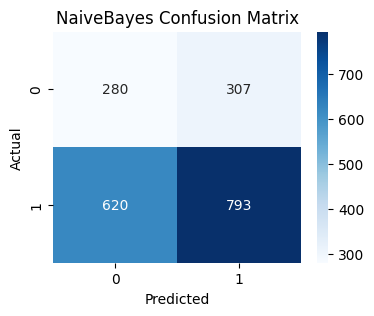

------------------------------------------------------------
AdaBoost
Accuracy: 0.7065
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       587
           1       0.71      1.00      0.83      1413

    accuracy                           0.71      2000
   macro avg       0.35      0.50      0.41      2000
weighted avg       0.50      0.71      0.58      2000



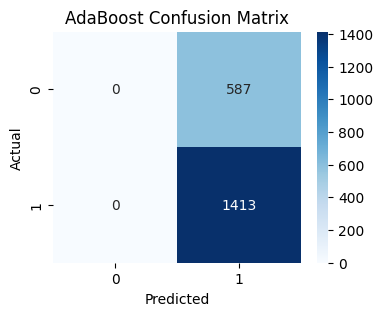

Saved models to ..\models\usedAgain/


In [25]:

for name, model in models.items():
    print('------------------------------------------------------------')
    print(name)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print('Accuracy:', round(acc, 4))
    print(classification_report(y_test, preds, zero_division=0))
    cm = confusion_matrix(y_test, preds)
    fig, ax = plt.subplots(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.show()
    joblib.dump(model, models_dir / f'usedagain_{name.lower()}.joblib')

print(f'Saved models to {models_dir}/')


In [26]:
# Compare model performance in a table
comparison_rows = []

for name, model in models.items():
    predictions = model.predict(X_test)
    report = classification_report(y_test, predictions, zero_division=0, output_dict=True)
    comparison_rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, predictions), 4),
        'Precision': round(report['macro avg']['precision'], 4),
        'Recall': round(report['macro avg']['recall'], 4),
        'F1-score': round(report['macro avg']['f1-score'], 4)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
comparison_df


,Model,Accuracy,Precision,Recall,F1-score
0,AdaBoost,0.7065,0.3533,0.5000,0.4140
1,RandomForest,0.6990,0.5386,0.5051,0.4429
2,KNN,0.6570,0.5247,0.5153,0.5035
3,NaiveBayes,0.5365,0.5160,0.5191,0.5039
4,SVM,0.5335,0.5126,0.5150,0.5004
5,LogisticRegression,0.5170,0.5098,0.5118,0.4915
